In [216]:
%pip install -q numpy pandas matplotlib torch torchvision torchmetrics scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [217]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

In [223]:
# defining custom object to store hyperparameter configs and error rate outputs 
class ffObject(object):

    def __init__(self, experiment_type, epochs, hidden_nodes, hidden_layers,
                 init_mode, learning_rate, dropout, act_type, model=None):

        self.experiment_type = experiment_type
        self.epochs = epochs
        self.hidden_nodes = hidden_nodes
        self.hidden_layers = hidden_layers
        self.init_mode = init_mode
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.act_type = act_type
        self.model = model

        self.train_error = 0.0
        self.validation_error = 0.0
        self.test_error = 0.0

        self.train_f1_measure = 0.0
        self.validation_f1_measure = 0.0
        self.test_f1_measure = 0.0
        

        self.training_error_epoch = []
        self.validation_error_epoch = []
        self.testing_error_epoch = []


def make_ffObject(experiment_type, epochs, hidden_nodes,
                  hidden_layers, init_mode, learning_rate, dropout, act_type):
    
    return ffObject(experiment_type, epochs, hidden_nodes,
                    hidden_layers, init_mode, learning_rate, dropout, act_type)


In [175]:
# device config 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparameters 
input_size = 3072
hidden_size = 2 # [2 - 300]  --> this is the hidden neurons not hidden layer 
num_classes = 10
num_epochs = 4
batch_size = 250
learning_rate = 0.0005 #[0.0005 - 0.5] try different rates here
init_wb_mode = "random" #can be: random or zero 

# import CIFAR 10 data set 
# need to split training dataset in 90/10 to use for training error rates and then final validation error rates 
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                             transform=transforms.ToTensor(), download=True)
training_size = 45000
validation_size = 5000

split_seed = torch.Generator().manual_seed(42)
training_dataset, validation_dataset = random_split(
    train_dataset,
    [training_size, validation_size],
    generator=split_seed
)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                             transform=transforms.ToTensor(), download=True)

# info from: https://www.geeksforgeeks.org/machine-learning/training-vs-testing-vs-validation-sets/
# Need a training dataset, a validation dataset and a testing data set for the following reasons: 
# Training set: is used to learn the patterns 
#   - this is the set that is used to fit the machine learning model, where the algorithm learns patterns, relationships, and parameters 
# Validation set: is used to tune and optimize the model 
#   - separate subset of data used to tune model hyperparameters and make design decisions during training. Provides an unbiased estimate of model performance during development
# Testing set: is used to measure the final performance and generalization 
#   - Completely independent subset used to evaluate the final model's performance after all training and tuning are complete. Simulates how the model will perform on unseen, real-world data and provides the most reliable estimate of generalization.  


train_loader = torch.utils.data.DataLoader(dataset=training_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# examples = iter(train_loader)
# samples, labels = examples.__next__()

# print(samples.shape, labels.shape)
# output: torch.Size([250, 3, 32, 32]) torch.Size([250])  
# samples shape; 250 -> batch size; 3 --> channels (colours: rgb); image array --> 32x32
# labels shape: 250 -> batch size 


# for i in range(6):
#     plt.subplot(2, 3, i+1)

#     img = samples[i].permute(1, 2, 0)  # (32,32,3)
#     plt.imshow(img)

# plt.show()


In [174]:
# Neural Network class using sigmoid --> contains the hidden layer as forward

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, hidden_layers, dropout, act_type):
        super(NeuralNet, self).__init__()

        self.dropout = nn.Dropout(p=dropout)

        if act_type == "sigmoid": 
            self.activation_type = nn.Sigmoid()  # defined as: f(x) = 1 / (1 + e^-x)
        elif act_type == "relu":
            self.activation_type = nn.ReLU() # defined as: f(x)=max(0,x)
        
        self.hidden_layers_count = hidden_layers

        # makes the hidden layer count visible to all modules methods (ie; forward)
        # more info can be found in pytorch docs here:
        #  https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html

        self.hidden_layers = nn.ModuleList()
        # self.layer = nn.Linear(input_size, hidden_size)


        self.hidden_layers.append(nn.Linear(input_size, hidden_size))

        for i in range(hidden_layers - 1 ):
            self.hidden_layers.append(nn.Linear(hidden_size, hidden_size))

        self.output = nn.Linear(hidden_size, num_classes)

    # this is the hidden layer and it is set to one as: input layer -> hidden layer : forward[l1 -> sigmoid -> l2] -> output layer
    def forward(self, x):
        x = self.dropout(x)
        out = x 

        for layer in self.hidden_layers:
            out = layer(out)
            out = self.activation_type(out)
        # out = self.layer(x) # layer one, gets x value 
        # out = self.sigmoid(out) # takes previous output and outputs new value: 
        
        
        # Sigmoid function outputs in the range (0, 1), it is ideal to use for binary classification problems 
        # works well for finding the probability of the data belonging to a particular class
        # can learn more about the sigmoid function here: https://www.geeksforgeeks.org/python/python-tensorflow-nn-sigmoid/
        out = self.output(out) # layer two, takes output from sigmoid 
        return out

In [ ]:
# used to initialize weights by type 
def init_weights_bias(model, mode="random"):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            if mode == "random":
                # need to init the weights here to random small value from a uniform distribution
                # bias can be set to zero 
                # reasoning behind using this for sigmid: https://www.geeksforgeeks.org/deep-learning/xavier-initialization/
                nn.init.uniform_(layer.weight)
                
                nn.init.zeros_(layer.bias)
            elif mode == "zero":
                nn.init.zeros_(layer.weight)
                nn.init.zeros_(layer.bias)


Experiment set up for Reusability

In [ ]:
# step a) batch size set to 250 --> rest of hyperparameters set to predetermined values 
# this is basically the baseline used for all other steps and will use these hyperparameters for each step besides the ones that need to modifying 


input_size = 3072
batch_size = 250
num_classes = 10


# baseline_setup = make_ffObject(experiment_type="baseline", epochs=4, hidden_nodes=150, hidden_layers=1, init_mode="zero", learning_rate=0.25)

def run_experiment(setupObj):
    model = NeuralNet(input_size, setupObj.hidden_nodes, num_classes, setupObj.hidden_layers, setupObj.dropout, setupObj.act_type).to(device)
    init_weights_bias(model, setupObj.init_mode)

    # loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=setupObj.learning_rate)

    n_total_steps = len(train_loader)

    for epoch in range(setupObj.epochs):
        model.train()

        for i, (images, labels) in enumerate(train_loader):
            
            # need to reshape data properly  
            images = images.reshape(images.size(0), -1).to(device)
            labels = labels.to(device)

            # forward pass 
            outputs = model(images)
            loss = criterion(outputs, labels) 

            # backwards pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # if (i+1) % 100 == 0:
            #     print(f'epoch {epoch+1} / {setupObj.epochs}, step {i+1} / {n_total_steps}, Training loss = {loss.item():4f}')


        # used to get train error rates per epoch 
        model.eval()
        with torch.no_grad():
            n_correct_train = 0
            n_samples_train= 0

            for images, labels, in train_loader:
                images = images.reshape(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predications = torch.max(outputs, 1)
                
                n_samples_train += labels.shape[0]
                n_correct_train += (predications == labels).sum().item()
            setupObj.training_error_epoch.append(1 - (n_correct_train / n_samples_train))
            # print(f'Train Error Rate: {setupObj.training_error_epoch[epoch]}')

        # used to get test error rates per epoch 

        model.eval()
        with torch.no_grad():
            n_correct_validation = 0
            n_samples_validation = 0

            for images, labels, in validation_loader:
                images = images.reshape(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predictions = torch.max(outputs, 1)

                n_samples_validation += labels.shape[0]
                n_correct_validation += (predictions == labels).sum().item()
            setupObj.validation_error_epoch.append(1 - (n_correct_validation / n_samples_validation))


    # might move this to my run eval method as I dont need f1 measure for a lot of this assignment and this will slow it down a bit 

    # computes training f1-measure once in total - not per epoch
    model.eval()
    all_labels_train = []
    all_predication_train = []
    with torch.no_grad():
        for images, labels, in train_loader:
                images = images.reshape(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predictions = torch.max(outputs, 1)

                all_labels_train.extend(labels.cpu().numpy())
                all_predication_train.extend(predications.cpu().numpy())
    setupObj.train_f1_measure = f1_score(all_labels_train, all_predication_train, average="macro")


    # computes validation f1-measure once in total - not per epoch
    model.eval()
    all_labels_validation = []
    all_predication_validation = []
    with torch.no_grad():
        for images, labels, in validation_loader:
                images = images.reshape(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predictions = torch.max(outputs, 1)

                all_labels_validation.extend(labels.cpu().numpy())
                all_predication_validation.extend(predications.cpu().numpy())
    setupObj.validation_f1_measure = f1_score(all_labels_validation, all_predication_validation, average="macro")
            
        

    setupObj.train_error = setupObj.training_error_epoch[-1]
    setupObj.validation_error = setupObj.validation_error_epoch[-1]

    setupObj.model = model

    return setupObj

Testing Setup for Reusability 

In [219]:
def run_eval(model, loader, device):

    n_correct = 0
    n_samples = 0
    all_labels = []
    all_predications = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.reshape(images.size(0), -1).to(device)
            labels = labels.to(device)
            outputs = model(images)

            _, predictions = torch.max(outputs, 1) 
            n_samples += labels.shape[0]
            n_correct += (predictions == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predications.extend(predictions.cpu().numpy())

    error_rate = 1 - (n_correct / n_samples)
    # params: y_true --> 1D labels array, y_pred --> 1D labels array,   
    f1_measure = f1_score(y_true=all_labels, y_pred=all_predications)

    return error_rate, f1_measure

    # print(f'Test Error Rate: {setupObj.testing_error_epoch[epoch]} \n')

# print(f'Epoch {epoch} Complete')



Step A: Baseline batch size set to 250

In [181]:
baseline_setup = make_ffObject(
    experiment_type="baseline",
    epochs=4,
    hidden_nodes=150,
    hidden_layers=1,
    init_mode="random",
    learning_rate=0.01,
    dropout=0.0,
    act_type="sigmoid"
)

baseline_setup = run_experiment(baseline_setup)

print("Final Train Error:", baseline_setup.train_error)
print("Final Validation Error:", baseline_setup.validation_error)


Final Train Error: 0.6857111111111112
Final Validation Error: 0.6861999999999999


Step B: Different Epoch Values 

In [182]:
epoch_range = [2, 4, 6, 8]
varying_epoch = []
for e in epoch_range:
    varying_epoch_setup = make_ffObject(
        experiment_type="epoch",
        epochs= e,
        hidden_nodes=150,
        hidden_layers=1,
        init_mode="random",
        learning_rate=0.01,
        dropout=0.0,
        act_type="sigmoid"
    )

    single_epoch_range_run = run_experiment(varying_epoch_setup)
    varying_epoch.append(single_epoch_range_run)

    print(f"Epoch Count: {e}")
    print("Final Train Error:", single_epoch_range_run.train_error)
    print("Final Validation Error:", single_epoch_range_run.validation_error)
    print("----------------------------- \n")


Epoch Count: 2
Final Train Error: 0.7239777777777778
Final Validation Error: 0.72
----------------------------- 

Epoch Count: 4
Final Train Error: 0.6906444444444444
Final Validation Error: 0.6926
----------------------------- 

Epoch Count: 6
Final Train Error: 0.6671111111111111
Final Validation Error: 0.6698
----------------------------- 

Epoch Count: 8
Final Train Error: 0.6556222222222222
Final Validation Error: 0.6604
----------------------------- 



Step C: Varying hidden nodes 

In [183]:
hidden_node_range = range(2, 300, 37)
varying_hidden_nodes = []

for h in hidden_node_range:
    varying_hidden_node_setup = make_ffObject(
        experiment_type="hidden_nodes",
        epochs=4,
        hidden_nodes=h,
        hidden_layers=1,
        init_mode="random",
        learning_rate=0.01,
        dropout=0.0,
        act_type="sigmoid"   
    )

    single_hidden_node_range_run = run_experiment(varying_hidden_node_setup)
    varying_hidden_nodes.append(single_hidden_node_range_run)

    print(f"Hidden Node Count: {h}")
    print("Final Train Error:", single_hidden_node_range_run.train_error)
    print("Final Validation Error:", single_hidden_node_range_run.validation_error)
    print("----------------------------- \n")

Hidden Node Count: 2
Final Train Error: 0.8729333333333333
Final Validation Error: 0.868
----------------------------- 

Hidden Node Count: 39
Final Train Error: 0.7285555555555556
Final Validation Error: 0.7352000000000001
----------------------------- 

Hidden Node Count: 76
Final Train Error: 0.6878666666666666
Final Validation Error: 0.6961999999999999
----------------------------- 

Hidden Node Count: 113
Final Train Error: 0.6879333333333333
Final Validation Error: 0.6994
----------------------------- 

Hidden Node Count: 150
Final Train Error: 0.6859555555555555
Final Validation Error: 0.6994
----------------------------- 

Hidden Node Count: 187
Final Train Error: 0.6819999999999999
Final Validation Error: 0.6826
----------------------------- 

Hidden Node Count: 224
Final Train Error: 0.6844222222222223
Final Validation Error: 0.6794
----------------------------- 

Hidden Node Count: 261
Final Train Error: 0.6808888888888889
Final Validation Error: 0.6821999999999999
---------

Step D: Different Initialization Methods 

In [184]:
init_type_range = ["random", "zero"]
varying_init_types = []

for t in init_type_range:
    varying_init_types_setup = make_ffObject(
        experiment_type="initialization_types",
        epochs=4,
        hidden_nodes=150,
        hidden_layers=1,
        init_mode=t,
        learning_rate=0.01,
        dropout=0.0,
        act_type="sigmoid"
    )

    single_init_type_range_run = run_experiment(varying_init_types_setup)
    varying_init_types.append(single_init_type_range_run)

    print(f"Initialization type: {t}")
    print("Final Train Error:", single_init_type_range_run.train_error)
    print("Final Validation Error:", single_init_type_range_run.validation_error)
    print("----------------------------- \n")

Initialization type: random
Final Train Error: 0.6828666666666667
Final Validation Error: 0.692
----------------------------- 

Initialization type: zero
Final Train Error: 0.9003111111111111
Final Validation Error: 0.8972
----------------------------- 



Step E: Varying Leaning Rate Types 

In [185]:
learning_rate_range = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
varying_learning_rates = []

for l in learning_rate_range:
    varying_learning_rate_setup = make_ffObject(
        experiment_type="learning_rates",
        epochs=4,
        hidden_nodes=150,
        hidden_layers=1,
        init_mode="random",
        learning_rate=l,
        dropout=0.0, 
        act_type="sigmoid"
    )

    single_learning_rate_range_run = run_experiment(varying_learning_rate_setup)
    varying_learning_rates.append(single_learning_rate_range_run)

    print(f"Learning Rate Value: {l}")
    print("Final Train Error:", single_learning_rate_range_run.train_error)
    print("Final Validation Error:", single_learning_rate_range_run.validation_error)
    print("----------------------------- \n")

Learning Rate Value: 0.0005
Final Train Error: 0.8445333333333334
Final Validation Error: 0.8434
----------------------------- 

Learning Rate Value: 0.001
Final Train Error: 0.8258222222222222
Final Validation Error: 0.8302
----------------------------- 

Learning Rate Value: 0.005
Final Train Error: 0.7046222222222223
Final Validation Error: 0.7106
----------------------------- 

Learning Rate Value: 0.01
Final Train Error: 0.6817777777777778
Final Validation Error: 0.6886
----------------------------- 

Learning Rate Value: 0.05
Final Train Error: 0.6360444444444444
Final Validation Error: 0.6422
----------------------------- 

Learning Rate Value: 0.1
Final Train Error: 0.6204222222222222
Final Validation Error: 0.6244000000000001
----------------------------- 

Learning Rate Value: 0.5
Final Train Error: 0.5758
Final Validation Error: 0.5878
----------------------------- 



Step F: Varying Hidden Layers

In [186]:
hidden_layer_range = [1, 2, 3, 4, 5, 6, 7, 8]
varying_hidden_layers = []

for h in hidden_layer_range:
    varying_hidden_layer_setup = make_ffObject(
        experiment_type="hidden_layers",
        epochs=4,
        hidden_nodes=150,
        hidden_layers=h,
        init_mode="random",
        learning_rate=0.01,
        dropout=0.0, 
        act_type="sigmoid"
    )

    single_hidden_layer_range_run = run_experiment(varying_hidden_layer_setup)
    varying_hidden_layers.append(single_hidden_layer_range_run)

    print(f"Hidden Layer Count: {h}")
    print("Final Train Error:", single_hidden_layer_range_run.train_error)
    print("Final Validation Error:", single_hidden_layer_range_run.validation_error)
    print("----------------------------- \n")

Hidden Layer Count: 1
Final Train Error: 0.6882444444444444
Final Validation Error: 0.6912
----------------------------- 

Hidden Layer Count: 2
Final Train Error: 0.7532888888888889
Final Validation Error: 0.7674
----------------------------- 

Hidden Layer Count: 3
Final Train Error: 0.8674
Final Validation Error: 0.8738
----------------------------- 

Hidden Layer Count: 4
Final Train Error: 0.9007111111111111
Final Validation Error: 0.8936
----------------------------- 

Hidden Layer Count: 5
Final Train Error: 0.9003111111111111
Final Validation Error: 0.8972
----------------------------- 

Hidden Layer Count: 6
Final Train Error: 0.8993555555555556
Final Validation Error: 0.9057999999999999
----------------------------- 

Hidden Layer Count: 7
Final Train Error: 0.9000888888888889
Final Validation Error: 0.8992
----------------------------- 

Hidden Layer Count: 8
Final Train Error: 0.8993555555555556
Final Validation Error: 0.9057999999999999
----------------------------- 



Step G: Varying dropout rates

In [187]:
dropout_rates_range = [0.2, 0.3, 0.4, 0.5]
varying_dropout_rates = []

for d in dropout_rates_range:
    varying_dropout_rates_setup = make_ffObject(
        experiment_type="hidden_layers",
        epochs=4,
        hidden_nodes=150,
        hidden_layers=1,
        init_mode="random",
        learning_rate=0.01,
        dropout=d, 
        act_type="sigmoid"
    )
    single_dropout_rate_range_run = run_experiment(varying_dropout_rates_setup)
    varying_dropout_rates.append(single_dropout_rate_range_run)

    print(f"Dropout Rate Value: {d}")
    print("Final Train Error:", single_dropout_rate_range_run.train_error)
    print("Final Validation Error:", single_dropout_rate_range_run.validation_error)
    print("----------------------------- \n")


Dropout Rate Value: 0.2
Final Train Error: 0.6920666666666666
Final Validation Error: 0.6946
----------------------------- 

Dropout Rate Value: 0.3
Final Train Error: 0.6952444444444444
Final Validation Error: 0.6914
----------------------------- 

Dropout Rate Value: 0.4
Final Train Error: 0.6981333333333333
Final Validation Error: 0.6996
----------------------------- 

Dropout Rate Value: 0.5
Final Train Error: 0.6974
Final Validation Error: 0.7018
----------------------------- 



Final Test Error

In [212]:
best_setup = make_ffObject(
    experiment_type="hidden_layers",
    epochs=8,
    hidden_nodes=224,
    hidden_layers=1,
    init_mode="random",
    learning_rate=0.5,
    dropout=0.3,
    act_type="sigmoid"
)

best_setup = run_experiment(best_setup)
final_test_error = run_test(best_setup.model, test_loader, device)

print("Optimized Parameter Setup:")
print(f"Testing Error Rate: {final_test_error}")

Optimized Parameter Setup:
Testing error Rate: 0.5775


Analysis for Each Step: 

Step A: Analysis

In [188]:
baseline_results = pd.DataFrame({
    "Epochs": [baseline_setup.epochs],
    "Training Error Rate": [baseline_setup.train_error],
    "Validation Error Rate": [baseline_setup.validation_error]
})

print(baseline_results)

   Epochs  Training Error Rate  Validation Error Rate
0       4             0.685711                 0.6862


Analysis for step A goes here

Step B: Analysis 

   Epochs  Training Error Rate  Validation Error Rate
0       2             0.723978                 0.7200
1       4             0.690644                 0.6926
2       6             0.667111                 0.6698
3       8             0.655622                 0.6604


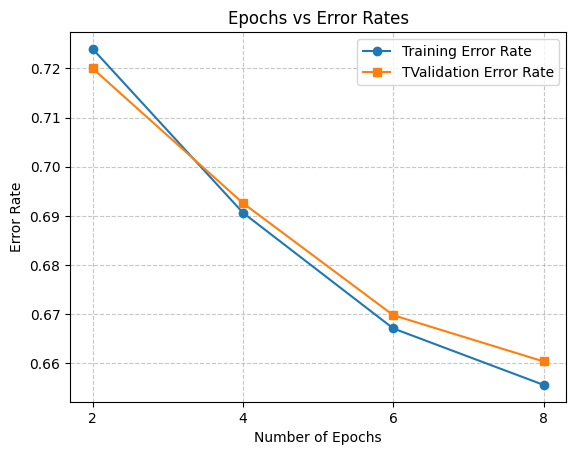

In [211]:
# print(varying_epoch[0])

epochs = [obj.epochs for obj in varying_epoch]
train_errors = [obj.train_error for obj in varying_epoch]
validation_errors = [obj.validation_error for obj in varying_epoch]

epoch_results = pd.DataFrame({
    "Epochs": epochs,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(epoch_results)
# print(epochs)
# print(train_errors)
# print(test_errors)


plt.plot(epochs, train_errors, marker='o', label="Training Error Rate")
plt.plot(epochs, validation_errors, marker='s', label="TValidation Error Rate")

plt.title('Epochs vs Error Rates')
plt.xlabel("Number of Epochs")
plt.ylabel("Error Rate")
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()



step b analysis goes here

Step C: Analysis 

   Hidden Nodes  Training Error Rate  Validation Error Rate
0             2             0.872933                 0.8680
1            39             0.728556                 0.7352
2            76             0.687867                 0.6962
3           113             0.687933                 0.6994
4           150             0.685956                 0.6994
5           187             0.682000                 0.6826
6           224             0.684422                 0.6794
7           261             0.680889                 0.6822
8           298             0.681178                 0.6866


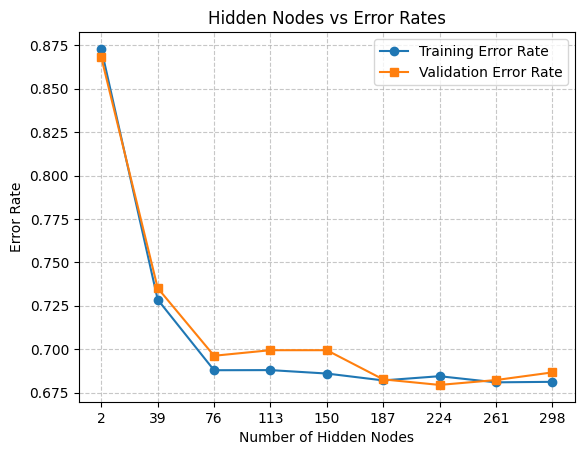

In [210]:
hidden_nodes = [obj.hidden_nodes for obj in varying_hidden_nodes]
train_errors = [obj.train_error for obj in varying_hidden_nodes]
validation_errors = [obj.validation_error for obj in varying_hidden_nodes]


hidden_nodes_result = pd.DataFrame({
    "Hidden Nodes": hidden_nodes,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(hidden_nodes_result)

plt.plot(hidden_nodes, train_errors, marker='o', label="Training Error Rate")
plt.plot(hidden_nodes, validation_errors, marker='s', label="Validation Error Rate")

plt.title('Hidden Nodes vs Error Rates')
plt.xlabel("Number of Hidden Nodes")
plt.ylabel("Error Rate")
plt.xticks(hidden_nodes)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

step c analysis goes here

Step D: Analysis

  Initialization Type  Training Error Rate  Validation Error Rate
0              random             0.682867                 0.6920
1                zero             0.900311                 0.8972


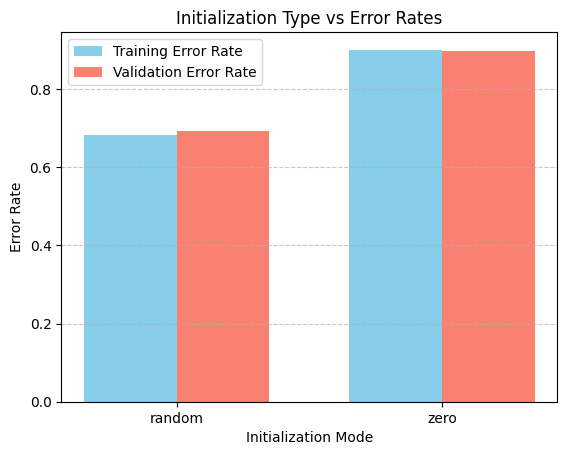

In [209]:
init_type = [obj.init_mode for obj in varying_init_types]
train_errors = [obj.train_error for obj in varying_init_types]
validation_errors = [obj.validation_error for obj in varying_init_types]


hidden_nodes_result = pd.DataFrame({
    "Initialization Type": init_type,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(hidden_nodes_result)

x = np.arange(len(init_type))  # Positions [0, 1]
width = 0.35  # Width of each bar

# 3. Create the bars directly with plt
plt.bar(x - width/2, train_errors, width, label='Training Error Rate', color='skyblue')
plt.bar(x + width/2, validation_errors, width, label='Validation Error Rate', color='salmon')

# 4. Add labels and formatting
plt.title('Initialization Type vs Error Rates')
plt.xlabel('Initialization Mode')
plt.ylabel('Error Rate')
plt.xticks(x, init_type) # Sets labels to "random" and "zero"
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

step d analysis goes here

Step E: Analysis 

   Learning Rate  Training Error Rate  Validation Error Rate
0         0.0005             0.844533                 0.8434
1         0.0010             0.825822                 0.8302
2         0.0050             0.704622                 0.7106
3         0.0100             0.681778                 0.6886
4         0.0500             0.636044                 0.6422
5         0.1000             0.620422                 0.6244
6         0.5000             0.575800                 0.5878


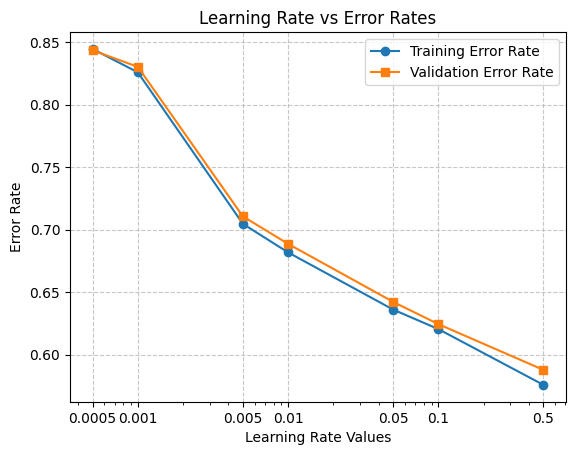

In [208]:
learning_rates = [obj.learning_rate for obj in varying_learning_rates]
train_errors = [obj.train_error for obj in varying_learning_rates]
validation_errors = [obj.validation_error for obj in varying_learning_rates]


varying_learning_rates_results = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(varying_learning_rates_results)

plt.plot(learning_rates, train_errors, marker='o', label="Training Error Rate")
plt.plot(learning_rates, validation_errors, marker='s', label="Validation Error Rate")
plt.xscale('log')

plt.title('Learning Rate vs Error Rates')
plt.xlabel("Learning Rate Values")
plt.ylabel("Error Rate")
plt.xticks(learning_rates, labels=[str(lr) for lr in learning_rates])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


step e analysis goes here 

Step F: Analysis 

   Hidden Layers  Training Error Rate  Validation Error Rate
0              1             0.688244                 0.6912
1              2             0.753289                 0.7674
2              3             0.867400                 0.8738
3              4             0.900711                 0.8936
4              5             0.900311                 0.8972
5              6             0.899356                 0.9058
6              7             0.900089                 0.8992
7              8             0.899356                 0.9058


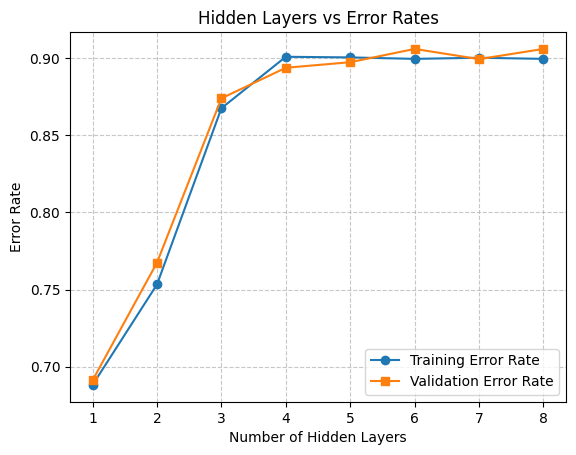

In [207]:
hidden_layers = [obj.hidden_layers for obj in varying_hidden_layers]
train_errors = [obj.train_error for obj in varying_hidden_layers]
validation_errors = [obj.validation_error for obj in varying_hidden_layers]


varying_hidden_layers_results = pd.DataFrame({
    "Hidden Layers": hidden_layers,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(varying_hidden_layers_results)


plt.plot(hidden_layers, train_errors, marker='o', label="Training Error Rate")
plt.plot(hidden_layers, validation_errors, marker='s', label="Validation Error Rate")

plt.title('Hidden Layers vs Error Rates')
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Error Rate")
plt.xticks(hidden_layers)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

step f analysis goes here

Step G: Analysis 

   Drop out Rate  Training Error Rate  Validation Error Rate
0            0.2             0.692067                 0.6946
1            0.3             0.695244                 0.6914
2            0.4             0.698133                 0.6996
3            0.5             0.697400                 0.7018


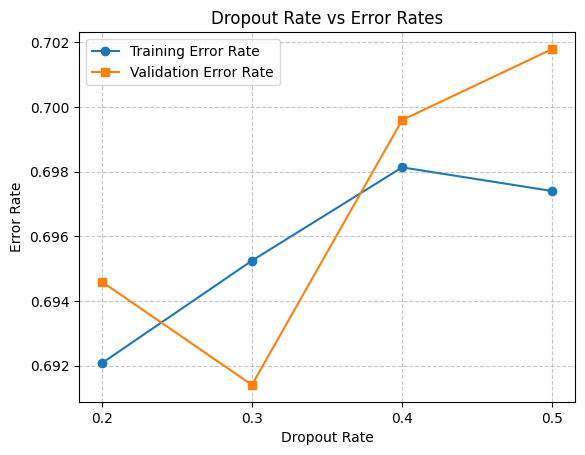

In [206]:
dropout = [obj.dropout for obj in varying_dropout_rates]
train_errors = [obj.train_error for obj in varying_dropout_rates]
validation_errors = [obj.validation_error for obj in varying_dropout_rates]


dropout_results = pd.DataFrame({
    "Drop out Rate": dropout,
    "Training Error Rate": train_errors,
    "Validation Error Rate": validation_errors
})

print(dropout_results)

plt.plot(dropout, train_errors, marker='o', label="Training Error Rate")
plt.plot(dropout, validation_errors, marker='s', label="Validation Error Rate")

plt.title('Dropout Rate vs Error Rates')
plt.xlabel("Dropout Rate")
plt.ylabel("Error Rate")
plt.xticks(dropout)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

step g analysis goes here

# Part 2

need the following: 
    - multiple hidden layers 
    - ReLU activation instead of sigmoid 
    - Softmax on the output layer
    - Use cross entropy 
    - softmax and cross entropy are combined with pytorch 

2.1: 
1) report: the error rate and f-measure for training and testing set 
2) my observations 

a: set parameters as follows:
i. use MGD for training - mini batch gradient decent 
ii. use random initialization 
iii. best number for hidden units from part 1 
iv. best value for hidden layers from part 1
v. best value for learning rate 
vi. change the values of epochs, use the best value 

for analysis plot diagrams and tables if needed to support reasoning 

In [230]:
relu_baseline_setup = make_ffObject(
    experiment_type="relu",
    epochs=8,
    hidden_nodes=261,
    hidden_layers=3,
    init_mode="random",
    learning_rate=0.5,
    dropout=0.0,
    act_type="relu"
)

relu_baseline_run = run_experiment(relu_baseline_setup)

print("Final Train Error:", relu_baseline_run.train_error)
print("Final Validation Error:", relu_baseline_run.validation_error)

print("Final Train f1-measure:", relu_baseline_run.train_f1_measure)
print("Final Validation f1-measure:", relu_baseline_run.validation_f1_measure)
print("----------------------------- \n")

Final Train Error: 0.8997333333333333
Final Validation Error: 0.9024
Final Train f1-measure: 1.0
Final Validation f1-measure: 0.017784256559766766
----------------------------- 



2.2: